# 13 - HNSW (Hierarchical Navigable Small World)
---

So far we have explored:

- Flat Index
- KDTree
- LSH
- IVF
- PQ
- IVFPQ

Each method improved search speed or memory.

Now we study one of the most successful modern ANN algorithms:

**HNSW**

Instead of trees or clusters,

HNSW builds a graph connecting similar vectors.

## History

Researchers wanted an ANN algorithm that offered:

- High recall
- Fast search
- Good scalability

Tree-based methods struggled in high dimensions.

Cluster-based methods required tuning.

Graph-based search became an attractive alternative.

This led to **Hierarchical Navigable Small World (HNSW)**.

##  Think Like a Researcher

Imagine Google Maps.

You don't visit every city to reach your destination.

Instead,

you travel through connected roads.

HNSW follows a similar idea.

Vectors become nodes.

Edges connect similar vectors.

Searching means navigating the graph instead of comparing every vector.

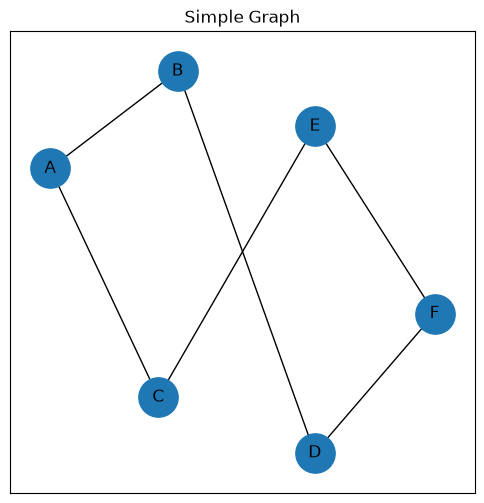

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

edges = [
    ("A","B"),
    ("A","C"),
    ("B","D"),
    ("C","E"),
    ("D","F"),
    ("E","F")
]

G.add_edges_from(edges)

plt.figure(figsize=(6,6))

nx.draw_networkx(
    G,
    node_size=800
)

plt.title("Simple Graph")

plt.show()

## Observation

Each node represents a vector.

Each edge connects nearby vectors.

Instead of checking every node,

we move through the graph toward better candidates.

## Multi-layer Graph

HNSW is not just one graph.

It consists of multiple layers.

```
Layer 3

        O

      /   \

Layer 2

   O------O

   |      |

Layer 1

O--O--O--O--O
```

Upper layers

↓

Fewer nodes

↓

Faster navigation

Lower layers

↓

More nodes

↓

Higher accuracy

## GPS Analogy

Suppose you're traveling from one city to another.

You first use

Highway

↓

Major Road

↓

Local Street

↓

Destination

HNSW follows the same strategy.

Start at higher layers,

then gradually move to lower layers.

## HNSW Search

```
Query

↓

Top Layer

↓

Find Better Neighbor

↓

Move Down

↓

Find Better Neighbor

↓

Move Down

↓

Nearest Vector
```

In [7]:
graph = {
    "A":["B","C"],
    "B":["A","D"],
    "C":["A","E"],
    "D":["B","F"],
    "E":["C","F"],
    "F":["D","E"]
}

graph

{'A': ['B', 'C'],
 'B': ['A', 'D'],
 'C': ['A', 'E'],
 'D': ['B', 'F'],
 'E': ['C', 'F'],
 'F': ['D', 'E']}

## Greedy Search

HNSW uses a greedy strategy.

At each step,

it moves to the neighboring node that appears closest to the query.

Instead of exploring the entire graph,

it follows promising paths.

## Important Parameters

### M

Maximum number of connections for each node.

Higher M

↓

Better recall

↓

More memory

---

### efConstruction

Controls search quality while building the graph.

Higher value

↓

Better graph

↓

Longer indexing time

---

### efSearch

Controls search quality.

Higher value

↓

Higher recall

↓

Slower search

In [9]:
import numpy as np

np.random.seed(42)

cluster1 = np.random.randn(30,2)+[2,2]
cluster2 = np.random.randn(30,2)+[8,2]
cluster3 = np.random.randn(30,2)+[5,8]

vectors = np.vstack([
    cluster1,
    cluster2,
    cluster3
])

In [12]:
query = np.array([4, 5], dtype=np.float32)

In [13]:
import faiss
import numpy as np

dimension = 2

index = faiss.IndexHNSWFlat(dimension, 32)

index.add(vectors.astype(np.float32))

distances, indices = index.search(
    query.astype(np.float32).reshape(1, -1),
    3
)

print(indices)

[[73  1 85]]


## Internal Working

```
Vectors

↓

Build Multi-layer Graph

↓

Connect Nearby Nodes

↓

Query

↓

Navigate Graph

↓

Nearest Neighbor
```

## Advantages

✅ Very fast

✅ High recall

✅ Excellent for high-dimensional embeddings

✅ Widely used in production

✅ No clustering required

## Limitations

❌ Graph construction takes time

❌ More memory than some compressed indexes

❌ Parameter tuning affects performance

## Comparison

| Method | Main Idea |
|----------|-----------|
| Flat | Compare every vector |
| KDTree | Partition space |
| LSH | Hash buckets |
| IVF | Cluster vectors |
| PQ | Compress vectors |
| IVFPQ | Cluster + Compress |
| HNSW | Graph navigation |

## Applications

HNSW is widely used in

- Vector Databases
- Semantic Search
- RAG
- Recommendation Systems
- Image Search
- Enterprise Search

## Summary

Today I learned:

- Graph-based search
- HNSW
- Multi-layer graphs
- Greedy navigation
- M
- efConstruction
- efSearch
- Why HNSW is widely used

## Think Like a Researcher


Now we understand the major indexing algorithms.

But one question remains.

How do developers actually use these algorithms in real applications?

Do they implement Flat, IVF, PQ, or HNSW from scratch?

Usually, no.

Instead, they use specialized libraries.

One of the most popular is **FAISS**, developed by Meta.